## TCGA CRC (cBioPortal) — Hippo-stratified DEGs Analysis

Because this cBioPortal cohort may have **no adjacent normals**, we will:
- use **Tumor-only** samples
- compute Hippo/YAP scores
- compare **Hippo-high vs Hippo-low** tumors (top 25% vs bottom 25%)

Outputs:
- `data_processed/tcga/tcga_log2_rsem.csv`
- `results/hippo/tcga_hippo_yap_scores.csv`
- `results/de/tcga/TCGA_DEG_HippoHigh_vs_HippoLow.csv`
- volcano plot in `results/figures/tcga/`


In [1]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [2]:

BASE = "/content/drive/MyDrive/Colon_cancer_project" # change accordingly

RAW_EXPR  = f"{BASE}/data_raw/tcga_coad/data_mrna_seq_v2_rsem.txt"
RAW_CLSMP = f"{BASE}/data_raw/tcga_coad/data_clinical_sample.txt"

OUT_PROC = f"{BASE}/data_processed/tcga"
OUT_DE   = f"{BASE}/results/de/tcga"
OUT_FIG  = f"{BASE}/results/figures/tcga"

import os
os.makedirs(OUT_PROC, exist_ok=True)
os.makedirs(OUT_DE,   exist_ok=True)
os.makedirs(OUT_FIG,  exist_ok=True)

print("EXPR:", RAW_EXPR)
print("CLIN:", RAW_CLSMP)



EXPR: /content/drive/MyDrive/Colon_cancer_project/data_raw/tcga_coad/data_mrna_seq_v2_rsem.txt
CLIN: /content/drive/MyDrive/Colon_cancer_project/data_raw/tcga_coad/data_clinical_sample.txt


In [3]:
import pandas as pd, numpy as np, re
from scipy.stats import ttest_ind
from statsmodels.stats.multitest import multipletests
import matplotlib.pyplot as plt
import seaborn as sns


In [4]:
expr = pd.read_csv(RAW_EXPR, sep="\t", comment="#")
print("Raw expr shape:", expr.shape)
display(expr.head())

# Detect gene column
gene_col = None
for c in expr.columns[:5]:
    if str(c).lower() in ["hugo_symbol","gene","symbol","gene_symbol","Hugo_Symbol"]:
        gene_col = c
        break
if gene_col is None:
    gene_col = expr.columns[0]
print("Using gene column:", gene_col)

expr = expr.dropna(subset=[gene_col])
expr[gene_col] = expr[gene_col].astype(str).str.strip()
expr = expr.set_index(gene_col)

# Drop Entrez column if present
for drop_c in ["Entrez_Gene_Id","entrez_gene_id","Entrez Gene Id"]:
    if drop_c in expr.columns:
        expr = expr.drop(columns=[drop_c])

expr = expr.apply(pd.to_numeric, errors="coerce").fillna(0)

dup = int(expr.index.duplicated().sum())
print("Duplicate genes:", dup)
if dup:
    expr = expr.groupby(expr.index).mean()

print("Clean expr shape:", expr.shape)


Raw expr shape: (20531, 594)


,Hugo_Symbol,Entrez_Gene_Id,TCGA-3L-AA1B-01,TCGA-4N-A93T-01,TCGA-4T-AA8H-01,TCGA-5M-AAT4-01,TCGA-5M-AAT5-01,TCGA-5M-AAT6-01,TCGA-5M-AATA-01,TCGA-5M-AATE-01,...,TCGA-AG-A01N-01,TCGA-AG-A01W-01,TCGA-AG-A01Y-01,TCGA-AG-A020-01,TCGA-AG-A025-01,TCGA-AG-A026-01,TCGA-AG-A02G-01,TCGA-AG-A02N-01,TCGA-AG-A02X-01,TCGA-AG-A032-01
0,NaN,100130426,0.5174,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,100133144,18.0851,4.4315,9.8995,7.9174,12.2565,3.9637,7.2366,11.629,...,15.743594,14.537972,21.727246,10.163220,12.410499,16.960418,15.046868,19.482340,10.879230,7.132114
2,UBE2Q2P2,100134869,15.7640,4.2767,11.3032,18.7608,20.8826,15.0672,11.4513,6.906,...,15.217727,16.618064,32.527797,12.122878,19.251253,22.282965,19.436783,2.815511,5.598328,13.724609
3,HMGB1P1,10357,144.4000,142.6610,143.1990,146.1880,262.5110,228.2520,124.2350,240.714,...,294.057306,447.567616,378.234898,354.662405,410.955520,289.758443,368.360542,333.491605,373.021521,409.240194
4,NaN,10431,774.6620,1185.2900,888.3200,1280.5500,1299.8400,945.6360,999.2050,606.849,...,785.354182,1709.628217,795.456492,931.667192,951.035450,946.999379,840.062409,892.839596,681.086971,804.159653


Using gene column: Hugo_Symbol
Duplicate genes: 7
Clean expr shape: (20511, 592)


Step 1: Load raw RNA expression data
Step 2: Identify gene symbol column
Step 3: Remove missing gene rows
Step 4: Clean gene naming format
Step 5: Set genes as row index
Step 6: Remove redundant ID columns
Step 7: Convert data to numeric matrix
Step 8: Handle duplicate genes
Step 9: Produce final clean expression matrix

In [5]:
clin = pd.read_csv(RAW_CLSMP, sep="\t", comment="#")
print("Clinical shape:", clin.shape)
display(clin.head())

cand_id = [c for c in clin.columns if re.search("sample|barcode|submitter", c, flags=re.I)]
sample_id_col = cand_id[0] if cand_id else clin.columns[0]
print("Sample ID col:", sample_id_col)
clin[sample_id_col] = clin[sample_id_col].astype(str).str.strip()

cand_type = [c for c in clin.columns if re.search("sample_type|tumor|normal", c, flags=re.I)]
if not cand_type:
    raise ValueError("Could not detect tumor/normal column. Open the file and pick the correct column name.")
type_col = cand_type[0]
print("Type col:", type_col)

clin[type_col] = clin[type_col].astype(str).str.lower()
clin["group"] = np.where(clin[type_col].str.contains("normal"), "Normal", "Tumor")

print("Group counts:")
display(clin["group"].value_counts())



Clinical shape: (594, 19)


,PATIENT_ID,SAMPLE_ID,ONCOTREE_CODE,CANCER_TYPE,CANCER_TYPE_DETAILED,TUMOR_TYPE,GRADE,TISSUE_PROSPECTIVE_COLLECTION_INDICATOR,TISSUE_RETROSPECTIVE_COLLECTION_INDICATOR,TISSUE_SOURCE_SITE_CODE,TUMOR_TISSUE_SITE,ANEUPLOIDY_SCORE,SAMPLE_TYPE,MSI_SCORE_MANTIS,MSI_SENSOR_SCORE,SOMATIC_STATUS,TMB_NONSYNONYMOUS,TISSUE_SOURCE_SITE,TBL_SCORE
0,TCGA-AF-2687,TCGA-AF-2687-01,READ,Colorectal Cancer,Rectal Adenocarcinoma,Rectal Adenocarcinoma,NaN,Yes,No,AF,Rectum,24.0,Primary,0.3529,0.08,Matched,3.266667,Albert Einstein Medical Center,46.0
1,TCGA-AF-2689,TCGA-AF-2689-01,READ,Colorectal Cancer,Rectal Adenocarcinoma,Rectal Adenocarcinoma,NaN,Yes,No,AF,Rectum,18.0,Primary,0.3486,1.28,Matched,1.733333,Mary Bird Perkins Cancer Center - Our Lady of ...,76.5
2,TCGA-AF-2690,TCGA-AF-2690-01,READ,Colorectal Cancer,Rectal Adenocarcinoma,Rectal Adenocarcinoma,NaN,Yes,No,AF,Rectum,25.0,Primary,0.3412,0.03,Matched,2.366667,Duke University,55.0
3,TCGA-AF-2691,TCGA-AF-2691-01,READ,Colorectal Cancer,Rectal Adenocarcinoma,Rectal Adenocarcinoma,NaN,Yes,No,AF,Rectum,11.0,Primary,0.3267,1.16,Matched,2.233333,University of Sao Paulo,19.5
4,TCGA-AF-2692,TCGA-AF-2692-01,READ,Colorectal Cancer,Rectal Adenocarcinoma,Rectum Adenocarcinoma,NaN,Yes,No,AF,NaN,16.0,Primary,0.3259,1.32,Matched,0.733333,University of Sao Paulo,49.0


Sample ID col: SAMPLE_ID
Type col: TUMOR_TYPE
Group counts:


,count
group,
Tumor,594


Step 1: Load Clinical Sample Data Step 2: Detect Sample ID Column( Cleaning Sample IDs: Converts sample IDs to string. Removes extra spaces.) Step 3: Detect Tumor vs Normal Column Step 4: Standardize Sample Type Labels Step 5: Create Tumor/Normal Group Label Step 6: Count Samples in Each Group (This code prepares clinical metadata to:

✔ Identify each biological sample
✔ Classify samples into tumor or normal groups
✔ Standardize labels for statistical analysis
✔ Enable merging with gene expression dataset)

In [6]:
# Detect which column contains gene names
possible_cols = ["Hugo_Symbol", "Hugo Symbol", "gene_symbol", "Gene", "Composite Element REF"]
detected_col = [c for c in possible_cols if c in expr.columns]

if detected_col:
    gene_col = detected_col[0]
    print(f"Using '{gene_col}' as the gene column.")
else:
    # If not found in columns, check if it's already the index
    if expr.index.name in possible_cols or not isinstance(expr.index, pd.RangeIndex):
        print("Genes appear to be in the index already.")
        # Skip the set_index step in your original code
    else:
        raise KeyError("Could not find a gene symbol column in expr.")


Genes appear to be in the index already.


1.Define expected gene column names
2.Search dataset columns for these names
3.If found → Use as gene identifier
4.If not found → Check if genes are already row index
5.If neither → Stop execution with error
(Correct identification of gene symbol location
✔ Compatibility across different dataset formats
✔ Prevention of incorrect indexing
✔ Error handling for missing gene identifiers)

Gemini


In [7]:
if gene_col not in expr.columns:
    print(f"Error: {gene_col} not found. Available columns: {expr.columns[:5].tolist()}...")
else:
    # Now run your original code
    expr = expr.dropna(subset=[gene_col]).copy()
    # ... rest of code

Error: Hugo_Symbol not found. Available columns: ['TCGA-3L-AA1B-01', 'TCGA-4N-A93T-01', 'TCGA-4T-AA8H-01', 'TCGA-5M-AAT4-01', 'TCGA-5M-AAT5-01']...


1.Confirms gene column exists
2.Provides helpful debugging information
3.Prevents downstream processing errors
4.Cleans dataset by removing missing gene identifiers

Gemini

In [8]:
# 1. Detect if genes are in the index
if expr.index.name is None or expr.index.name not in ["Hugo_Symbol", "Hugo Symbol"]:
    # Force the index name so subsequent code knows where the genes are
    expr.index.name = "Hugo_Symbol"

# 2. Assign the name to a variable for consistency
gene_col_name = expr.index.name

# 3. Clean up the index (equivalent to your original dropna/strip logic)
expr = expr[expr.index.notnull()].copy()
expr.index = expr.index.astype(str).str.strip()

# 4. Drop non-numeric columns if any exist (like Entrez ID)
for drop_c in ["Entrez_Gene_Id", "entrez_gene_id", "Entrez Gene Id"]:
    if drop_c in expr.columns:
        expr = expr.drop(columns=[drop_c])

# 5. Convert all sample columns to numeric
expr = expr.apply(pd.to_numeric, errors="coerce").fillna(0)

# 6. Merge duplicate genes if they exist
if expr.index.duplicated().sum() > 0:
    expr = expr.groupby(expr.index).mean()

print("Expression matrix shape:", expr.shape)
print("First few genes in index:", expr.index[:5].tolist())

Expression matrix shape: (20511, 592)
First few genes in index: ['A1BG', 'A1CF', 'A2BP1', 'A2LD1', 'A2M']


Gemini

1.Standardizes gene identifier location
2.Removes invalid gene entries
3.Cleans gene naming format
4.Removes redundant identifier columns
5.Converts data into numeric expression matrix
6.Merges duplicate genes
7.Produces analysis-ready dataset


In [9]:
import numpy as np
import re

# --- Identify the Sample ID column in Clinical Data ---
# We look for columns named 'sample', 'barcode', or 'submitter'
cand_id = [c for c in clin.columns if re.search("sample|barcode|submitter", c, flags=re.I)]
sample_id_col = cand_id[0] if cand_id else clin.columns[0]

# Standardize IDs: remove whitespace and convert to hyphens (TCGA standard)
clin[sample_id_col] = clin[sample_id_col].astype(str).str.strip().str.replace('.', '-', regex=False)
expr.columns = expr.columns.astype(str).str.strip().str.replace('.', '-', regex=False)

# --- Find the Overlap ---
overlap = expr.columns.intersection(clin[sample_id_col])
print(f"Overlap found: {len(overlap)} samples")

# Filter both dataframes to only include overlapping samples
expr = expr[overlap]
clin = clin[clin[sample_id_col].isin(overlap)].copy()

# Set index and sort to ensure perfect alignment
clin = clin.set_index(sample_id_col).loc[overlap].reset_index()

# --- Identify Tumor vs Normal ---
# Usually 'sample_type' or 'definition' columns tell us if it's "Primary Tumor" or "Solid Tissue Normal"
cand_type = [c for c in clin.columns if re.search("type|definition|status", c, flags=re.I)]
type_col = cand_type[0] if cand_type else None

if type_col:
    clin["group"] = np.where(clin[type_col].astype(str).str.lower().str.contains("normal"), "Normal", "Tumor")
else:
    clin["group"] = "Tumor" # Default if no type column is found

print("Final Groups:\n", clin["group"].value_counts())

Overlap found: 592 samples
Final Groups:
 group
Tumor    592
Name: count, dtype: int64




1.   Identifies matching samples between expression and clinical data
2. Standardizes sample ID formatting
3. Filters datasets to shared samples
4. Aligns clinical metadata with expression matrix
5. Classifies samples into Tumor and Normal groups
6. Produces clean, aligned dataset ready for analysis



Gemini

In [10]:
# 1. Log2 Transformation (Required for Z-scoring)
expr_log = np.log2(expr + 1)

def zscore_rows(df):
    return df.sub(df.mean(axis=1), axis=0).div(df.std(axis=1).replace(0, np.nan), axis=0)

def geneset_score(df, genes):
    # Filter for genes actually present in our 20,511 list
    present = [g for g in genes if g in df.index]
    if len(present) < 2:
        return np.zeros(df.shape[1])
    # Z-score and take the average per sample
    return zscore_rows(df.loc[present]).mean(axis=0)

# Define Hippo Pathway Signatures
HIPPO_CORE = ["STK3","STK4","SAV1","MOB1A","MOB1B","LATS1","LATS2","NF2"]
YAP_TARGETS = ["CTGF","CYR61","ANKRD1","AREG","AMOTL2","BIRC5","FSTL1"]

# Calculate Scores
scores = pd.DataFrame(index=expr_log.columns)
scores["hippo_core_score"] = geneset_score(expr_log, HIPPO_CORE)
scores["yap_targets_score"] = geneset_score(expr_log, YAP_TARGETS)

print("Scoring complete. Top 5 samples:")
print(scores.head())

Scoring complete. Top 5 samples:
                 hippo_core_score  yap_targets_score
TCGA-3L-AA1B-01          0.074920           0.153704
TCGA-4N-A93T-01         -0.572505          -0.642761
TCGA-4T-AA8H-01         -0.209411          -1.175349
TCGA-5M-AAT4-01          0.157117           0.042558
TCGA-5M-AAT5-01         -0.436849           0.115240


Step 1: Apply Log2 Transformation to Expression Data (Reduces large expression differences,Stabilizes variance across genes,Makes data suitable for normalization (Z-score)) 1+: Prevents undefined values from log(0).

step2: Normalizes gene expression across samples

step 3:Extracts Hippo pathway gene expression

step 4:Calculates pathway activity score per sample

step 5:Produces sample-level signaling activity matrix

Gemini

**Hippo/YAP gene sets + scoring**



Add log transformation for expression data then calculate scores for all three (3) genesets

In [11]:
## Log2 Transformation (Required for Z-scoring)
expr_log = np.log2(expr + 1)

def zscore_rows(expr_df):
    mu = expr_df.mean(axis=1)
    sd = expr_df.std(axis=1).replace(0, np.nan)
    return expr_df.sub(mu, axis=0).div(sd, axis=0)

def geneset_score(expr_log_df, genes):
    genes_present = [g for g in genes if g in expr_log_df.index]
    if len(genes_present) < 2:
        raise ValueError(f"Too few genes found from set. Found: {genes_present}")
    Z = zscore_rows(expr_log_df.loc[genes_present]).fillna(0)
    return Z.mean(axis=0)

HIPPO_CORE = ["STK3","STK4","SAV1","MOB1A","MOB1B","LATS1","LATS2","NF2"]
YAP_TAZ    = ["YAP1","WWTR1","TEAD1","TEAD2","TEAD3","TEAD4"]
YAP_TARGETS= ["CTGF","CYR61","ANKRD1","AREG","AMOTL2","BIRC5","FSTL1"]

scores = pd.DataFrame(index=expr_log.columns)
scores["hippo_core"]  = geneset_score(expr_log, HIPPO_CORE)
scores["yap_taz"]     = geneset_score(expr_log, YAP_TAZ)
scores["yap_targets"] = geneset_score(expr_log, YAP_TARGETS)

scores.to_csv(f"{BASE}/results/hippo/tcga_hippo_yap_scores.csv")
print("Saved ->", f"{BASE}/results/hippo/tcga_hippo_yap_scores.csv")
scores.head()


Saved -> /content/drive/MyDrive/Colon_cancer_project/results/hippo/tcga_hippo_yap_scores.csv


,hippo_core,yap_taz,yap_targets
TCGA-3L-AA1B-01,0.074920,0.199218,0.153704
TCGA-4N-A93T-01,-0.572505,-0.234551,-0.642761
TCGA-4T-AA8H-01,-0.209411,-0.422981,-1.175349
TCGA-5M-AAT4-01,0.157117,0.104939,0.042558
TCGA-5M-AAT5-01,-0.436849,0.175284,0.115240


Log-transforms gene expression data

Normalizes gene expression using Z-scores

Evaluates Hippo pathway regulatory activity

Measures YAP-TAZ transcriptional signaling

Measures downstream YAP target gene activation

Generates sample-level pathway activity scores

Saves results for downstream analysis


**Stratify Hippo-high vs Hippo-low (top/bottom 25%)**

In [12]:
score_col = "yap_targets"   # you can switch to hippo_core if you prefer

q_low  = scores[score_col].quantile(0.25)
q_high = scores[score_col].quantile(0.75)

scores["hippo_group"] = "mid"
scores.loc[scores[score_col] <= q_low,  "hippo_group"] = "Hippo_low"
scores.loc[scores[score_col] >= q_high, "hippo_group"] = "Hippo_high"

print(scores["hippo_group"].value_counts())

keep = scores["hippo_group"].isin(["Hippo_high","Hippo_low"])
expr_sub = expr_log.loc[:, keep]
grp = scores.loc[keep, "hippo_group"].values

print("Expr for DEG:", expr_sub.shape)
print("Hippo-high:", (grp=="Hippo_high").sum(), "Hippo-low:", (grp=="Hippo_low").sum())


hippo_group
mid           296
Hippo_low     148
Hippo_high    148
Name: count, dtype: int64
Expr for DEG: (20511, 296)
Hippo-high: 148 Hippo-low: 148


Selects pathway activity score

Defines high and low activity groups using quartiles

Removes middle group

Subsets expression matrix

Prepares dataset for differential gene expression analysis

**Safe Welch DEG (prevents NaN FDR)**

In [13]:
from scipy.stats import ttest_ind
from statsmodels.stats.multitest import multipletests

def deg_welch_safe(expr_log_df, groups, g1="Hippo_high", g2="Hippo_low", min_var=1e-8):
    groups = np.array(groups, dtype=str)
    i1 = np.where(groups == g1)[0]
    i2 = np.where(groups == g2)[0]
    print(f"Group sizes: {g1}={len(i1)} | {g2}={len(i2)}")

    X1 = expr_log_df.iloc[:, i1]
    X2 = expr_log_df.iloc[:, i2]

    mean1 = X1.mean(axis=1)
    mean2 = X2.mean(axis=1)
    logFC = mean1 - mean2

    var1 = X1.var(axis=1)
    var2 = X2.var(axis=1)
    valid_var = (var1 > min_var) | (var2 > min_var)

    pvals = np.full(expr_log_df.shape[0], np.nan, dtype=float)

    idx = np.where(valid_var.values)[0]
    for i in idx:
        pvals[i] = ttest_ind(X1.iloc[i,:], X2.iloc[i,:], equal_var=False, nan_policy="omit").pvalue

    padj = np.ones_like(pvals, dtype=float)
    valid_p = np.isfinite(pvals)
    if valid_p.sum() > 0:
        padj[valid_p] = multipletests(pvals[valid_p], method="fdr_bh")[1]

    out = pd.DataFrame({
        "gene": expr_log_df.index.astype(str),
        f"mean_{g1}": mean1.values,
        f"mean_{g2}": mean2.values,
        f"logFC_{g1}_minus_{g2}": logFC.values,
        "pval": pvals,
        "padj_fdr": padj
    }).sort_values(["padj_fdr","pval"], ascending=[True, True])

    return out

deg_tcga = deg_welch_safe(expr_sub, grp, "Hippo_high", "Hippo_low")
display(deg_tcga.head(15))

deg_tcga.to_csv(f"{OUT_DE}/TCGA_DEG_HippoHigh_vs_HippoLow.csv", index=False)
print("Saved ->", f"{OUT_DE}/TCGA_DEG_HippoHigh_vs_HippoLow.csv")


Group sizes: Hippo_high=148 | Hippo_low=148


,gene,mean_Hippo_high,mean_Hippo_low,logFC_Hippo_high_minus_Hippo_low,pval,padj_fdr
4638,CYR61,11.390036,8.705280,2.684756,6.636470e-73,1.324308e-68
4429,CTGF,12.135373,9.930079,2.205294,6.049885e-66,6.036273e-62
8854,KCNE4,7.471083,5.086596,2.384487,3.363832e-61,2.237509e-57
17000,SPARC,14.912396,12.670735,2.241661,1.444841e-59,7.207953e-56
6730,FSTL1,12.510999,10.493857,2.017142,1.535814e-58,6.129432e-55
2164,C1S,12.469859,10.145003,2.324856,7.677621e-58,2.553449e-54
8560,INHBA,8.539890,5.671393,2.868497,3.426926e-57,9.769186e-54
5358,DZIP1,6.861263,4.737208,2.124055,1.288233e-56,3.213337e-53
5461,EFS,6.662430,4.545800,2.116630,2.159184e-56,4.787392e-53
6418,FERMT2,9.367121,7.120992,2.246129,1.101399e-55,2.197842e-52


Saved -> /content/drive/MyDrive/Colon_cancer_project/results/de/tcga/TCGA_DEG_HippoHigh_vs_HippoLow.csv


1. Import statistical tools
2. Define DEG function
3. Identify sample indices for each group
4. Subset expression matrix by group
5. Compute mean expression per gene
6. Calculate log Fold Change (logFC)
7. Remove genes with near-zero variance
8. Perform Welch’s t-test per gene
9. Multiple testing correction (FDR)
10. Create output table
11. Run DEG analysis
12. Save results
This code performs a statistically robust differential gene expression analysis between Hippo_high and Hippo_low tumor samples using Welch’s t-test with FDR correction and outputs ranked significant genes.

Hippo HIgh vs. Hippo Low (Volcano plot)


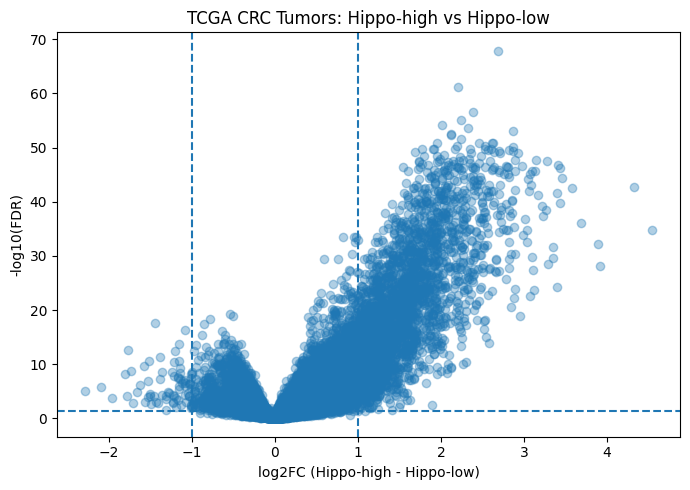

Saved -> /content/drive/MyDrive/Colon_cancer_project/results/figures/tcga/volcano_TCGA_HippoHigh_vs_HippoLow.png


In [14]:
df = deg_tcga.copy()
df["neglog10_fdr"] = -np.log10(df["padj_fdr"] + 1e-300)

plt.figure(figsize=(7,5))
plt.scatter(df["logFC_Hippo_high_minus_Hippo_low"], df["neglog10_fdr"], alpha=0.35)

plt.axvline(1, linestyle="--")
plt.axvline(-1, linestyle="--")
plt.axhline(-np.log10(0.05), linestyle="--")

plt.title("TCGA CRC Tumors: Hippo-high vs Hippo-low")
plt.xlabel("log2FC (Hippo-high - Hippo-low)")
plt.ylabel("-log10(FDR)")
plt.tight_layout()

out_png = f"{OUT_FIG}/volcano_TCGA_HippoHigh_vs_HippoLow.png"
plt.savefig(out_png, dpi=200)
plt.show()

print("Saved ->", out_png)


1. Copy DEG results
2. Convert FDR to −log10 scale
3. Create plotting canvas
4. Plot volcano scatter
5. Add fold change thresholds
6. Add statistical significance threshold
7. Add labels and title
8.Adjust layout,Save figure, display plot
This code generates and saves a volcano plot visualizing statistically significant and biologically meaningful gene expression differences between Hippo-high and Hippo-low TCGA CRC tumors.

Top 10 labeled DEGs

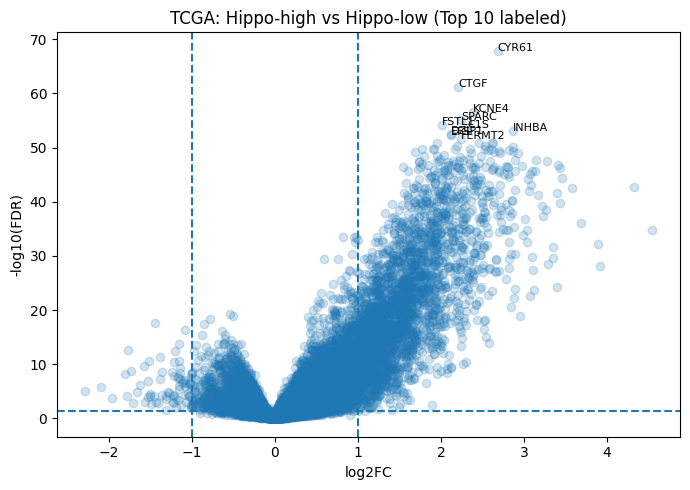

In [15]:
top = df.sort_values("padj_fdr").head(10)

plt.figure(figsize=(7,5))
plt.scatter(df["logFC_Hippo_high_minus_Hippo_low"], df["neglog10_fdr"], alpha=0.20)
plt.axvline(1, linestyle="--"); plt.axvline(-1, linestyle="--")
plt.axhline(-np.log10(0.05), linestyle="--")

for _, r in top.iterrows():
    plt.text(r["logFC_Hippo_high_minus_Hippo_low"], r["neglog10_fdr"], r["gene"], fontsize=8)

plt.title("TCGA: Hippo-high vs Hippo-low (Top 10 labeled)")
plt.xlabel("log2FC"); plt.ylabel("-log10(FDR)")
plt.tight_layout()
plt.show()


This code generates a volcano plot of Hippo-high vs Hippo-low CRC tumors and labels the 10 most statistically significant differentially expressed genes directly on the plot.

In [19]:
# Identify YAP target column
yap_col = [c for c in scores.columns if 'yap' in c.lower() and 'target' in c.lower()]

if not yap_col:
    print(f"Error: Could not find YAP target column. Available: {scores.columns.tolist()}")
else:
    target_col = yap_col[0]
    print(f"Using column: '{target_col}' for stratification.")

    # All samples in 'scores' are already tumor samples based on previous filtering.
    # So, we can consider all indices of 'scores' as valid tumor IDs for stratification.
    valid_tumor_ids = scores.index

    # Filter scores for matched tumor samples
    tumor_scores = scores.loc[valid_tumor_ids].copy()

    # Calculate quartiles
    q_low = tumor_scores[target_col].quantile(0.25)
    q_high = tumor_scores[target_col].quantile(0.75)

    # Assign groups
    tumor_scores["stratification"] = "Intermediate"
    tumor_scores.loc[tumor_scores[target_col] <= q_low, "stratification"] = "Hippo_Low"
    tumor_scores.loc[tumor_scores[target_col] >= q_high, "stratification"] = "Hippo_High"

    print("\n--- Stratification Results ---")
    print(tumor_scores["stratification"].value_counts())

    # Extract final IDs
    final_high_ids = tumor_scores[tumor_scores["stratification"] == "Hippo_High"].index
    final_low_ids = tumor_scores[tumor_scores["stratification"] == "Hippo_Low"].index

Using column: 'yap_targets' for stratification.

--- Stratification Results ---
stratification
Intermediate    296
Hippo_Low       148
Hippo_High      148
Name: count, dtype: int64


This code identifies the YAP target score column, stratifies all tumor samples into Hippo_High (top 25%), Hippo_Low (bottom 25%), and Intermediate groups based on quartiles of that score, and extracts the sample IDs for the high and low groups for downstream analysis.

Gemini

In [20]:
from scipy.stats import ttest_ind
import pandas as pd
import numpy as np

# 1. Calculate the mean expression for each group
# We use expr_log which we created earlier (the 20511 x 592 matrix)
mean_high = expr_log[final_high_ids].mean(axis=1)
mean_low = expr_log[final_low_ids].mean(axis=1)

# 2. Calculate Log2 Fold Change (L2FC)
# Since data is already log2, subtraction equals the log of the ratio
l2fc = mean_high - mean_low

# 3. Perform T-test to get p-values
# axis=1 performs the test for every gene (row)
t_stat, p_vals = ttest_ind(expr_log[final_high_ids],
                           expr_log[final_low_ids],
                           axis=1,
                           nan_policy='omit')

# 4. Create a clean results DataFrame
de_results = pd.DataFrame({
    "log2FC": l2fc,
    "pvalue": p_vals,
    "neg_log10_p": -np.log10(p_vals + 1e-100) # Adding a tiny value to avoid log(0)
}, index=expr_log.index).dropna()

print(f"DE Analysis complete for {len(de_results)} genes.")

DE Analysis complete for 19955 genes.


| Column      | Meaning                                    |
| ----------- | ------------------------------------------ |
| log2FC      | Expression difference between groups       |
| pvalue      | Raw statistical significance               |
| neg_log10_p | Transformed p-value for plotting (volcano) |
Calculate mean expression in each group
Calculate Log2 Fold Change (L2FC)
Perform independent t-test for each gene
Create differential expression results table
This code calculates log2 fold changes and performs gene-wise t-tests to identify genes differentially expressed between Hippo_High and Hippo_Low tumor samples.

Gemini

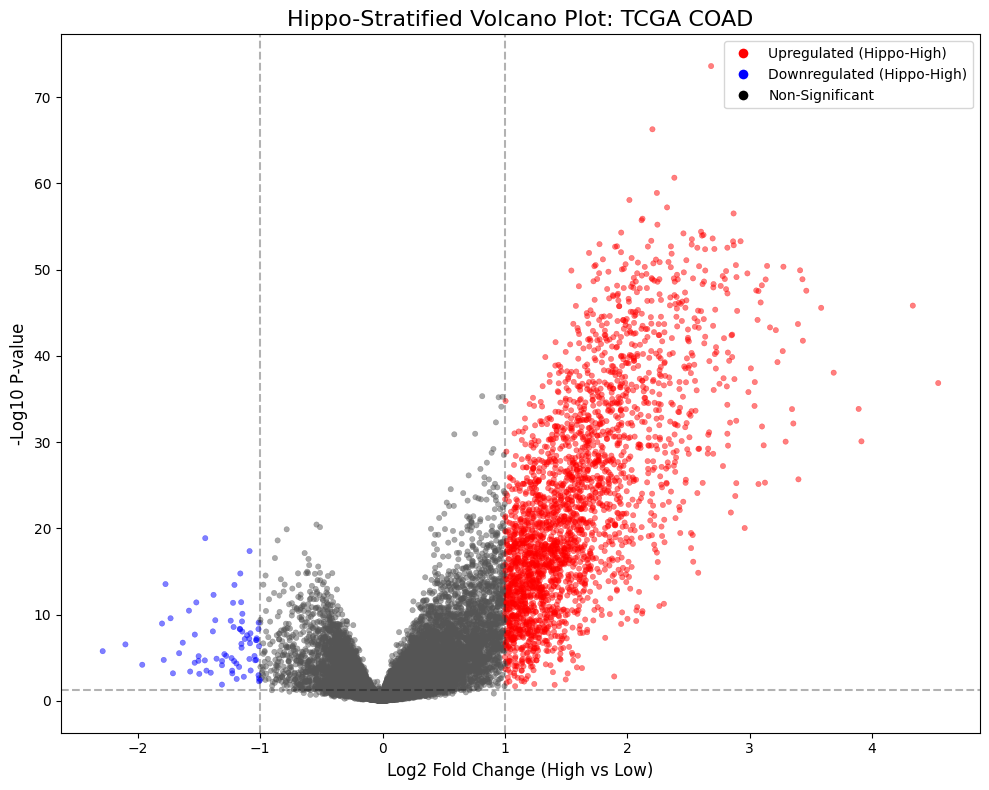

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set Thresholds
P_THRESH = 0.05
FC_THRESH = 1.0  # Represents a 2-fold difference

# Define the color logic
de_results['color'] = 'black'  # Default
de_results.loc[(de_results['log2FC'] > FC_THRESH) & (de_results['pvalue'] < P_THRESH), 'color'] = 'red'
de_results.loc[(de_results['log2FC'] < -FC_THRESH) & (de_results['pvalue'] < P_THRESH), 'color'] = 'blue'

# Plotting
plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=de_results,
    x='log2FC',
    y='neg_log10_p',
    hue='color',
    palette={'black': '#555555', 'red': '#FF0000', 'blue': '#0000FF'},
    alpha=0.5,
    s=15,
    edgecolor=None
)

# Add helper lines for significance thresholds
plt.axhline(-np.log10(P_THRESH), color='black', linestyle='--', alpha=0.3)
plt.axvline(FC_THRESH, color='black', linestyle='--', alpha=0.3)
plt.axvline(-FC_THRESH, color='black', linestyle='--', alpha=0.3)

# Labeling
plt.title("Hippo-Stratified Volcano Plot: TCGA COAD", fontsize=16)
plt.xlabel("Log2 Fold Change (High vs Low)", fontsize=12)
plt.ylabel("-Log10 P-value", fontsize=12)

# Custom legend to match your requirements
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Upregulated (Hippo-High)', markerfacecolor='red', markersize=8),
    Line2D([0], [0], marker='o', color='w', label='Downregulated (Hippo-High)', markerfacecolor='blue', markersize=8),
    Line2D([0], [0], marker='o', color='w', label='Non-Significant', markerfacecolor='black', markersize=8)
]
plt.legend(handles=legend_elements, loc='upper right')

plt.tight_layout()
plt.show()

🔴 Red genes

Strongly activated in Hippo_High tumors
→ Likely YAP/TEAD target genes
→ Possibly EMT, proliferation, invasion markers

🔵 Blue genes

Suppressed in Hippo_High tumors
→ Active in Hippo_Low tumors

⚫ Black genes

Not statistically or biologically significant

Gemini